#### Load H1 and H2 data

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('..')
from hypso.hypso2 import Hypso2
from hypso.hypso1 import Hypso1

#### load RadCalNet

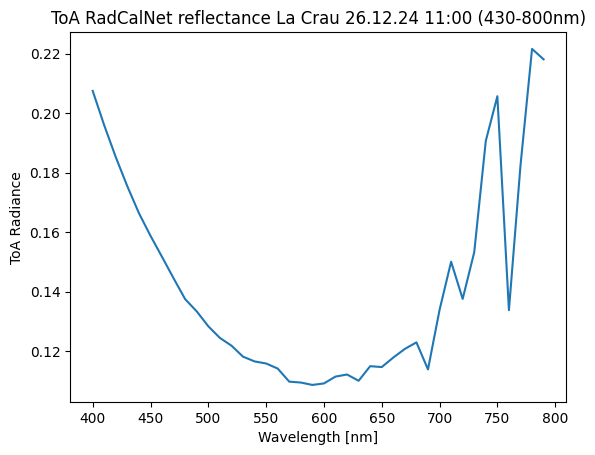

In [2]:
# Read the ASCII ToA data

file_path = '../../data/h2_lacrau_2024-12-26T11-15-54/RadCalNet/LCFR01_2024_361_v04.06.output'

def read_radcalnet_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize variables to store header and data
    header = []
    atmos_data = []
    ToA_reflectance = []
    ToA_uncertainty = []

    # State variable to track which part of the file we are reading
    state = 'header'

    for line in lines:
        stripped_line = line.strip()
        
        if state == 'header':
            if stripped_line == '':
                state = 'atmos_data'
            else:
                split_line = stripped_line.split('\t')
                header.append(split_line)
        elif state == 'atmos_data':
            if stripped_line == '':
                state = 'ToA_reflectance'
            else:
                split_line = stripped_line.split('\t')
                atmos_data.append(split_line)
        elif state == 'ToA_reflectance':
            if stripped_line == '' and len(ToA_reflectance) != 0:
                state = 'ToA_uncertainty'
            else:
                if stripped_line != '':
                    split_line = stripped_line.split('\t')
                    ToA_reflectance.append(split_line)
        elif state == 'ToA_uncertainty':
            if stripped_line != '':
                split_line = stripped_line.split('\t')
                ToA_uncertainty.append(split_line)
    header_ar = np.array(header)
    atmos_data_ar = np.array(atmos_data)
    ToA_reflectance_ar = np.array(ToA_reflectance, dtype=float)
    ToA_uncertainty_ar = np.array(ToA_uncertainty)


    return header_ar, atmos_data_ar, ToA_reflectance_ar, ToA_uncertainty_ar

header, atmos_data, ToA_reflectance, ToA_uncertainty = read_radcalnet_file(file_path)

plt.figure()
plt.title('ToA RadCalNet reflectance La Crau 26.12.24 11:00 (430-800nm)')
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Radiance')
plt.plot(ToA_reflectance[:40,0], ToA_reflectance[:40, 4])

### H1 and H2

In [3]:
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'
l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'

points_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-scaled_test.points'
points_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-scaled_test.points'

In [4]:
satobj_h1 = Hypso1(path=l1a_nc_file_h1, points_path= points_h1, verbose=True)
satobj_h2 = Hypso2(path=l1a_nc_file_h2, points_path= points_h2, verbose=True)
# satobj_h1 = Hypso1(path=l1a_nc_file_h1, verbose=True)
# satobj_h2 = Hypso2(path=l1a_nc_file_h2, verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T10-24-27Z


[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide
[INFO] Running georeferencing...
No image mode provided. Detected image mode: bin3
[INFO] Using UTM map: WGS 84 / UTM zone 31N EPSG: 32631
[INFO] Loading L1a capture lacrau_2024-12-26T11-15-54Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide
[INFO] Running georeferencing...
No image mode provided. Detected image mode: bin3


/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:97: RuntimeWarning: invalid value encountered in scalar divide
  cos_vel_angle = (vel[0]*body_x_teme[0] + vel[1]*body_x_teme[1] + vel[2]*body_x_teme[2]) / vellen
/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:97: RuntimeWarning: divide by zero encountered in scalar divide
  cos_vel_angle = (vel[0]*body_x_teme[0] + vel[1]*body_x_teme[1] + vel[2]*body_x_teme[2]) / vellen
/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:96: RuntimeWarning: overflow encountered in scalar power
  vellen = m.sqrt(vel[0]**2 + vel[1]**2 + vel[2]**2)


[INFO] Using UTM map: WGS 84 / UTM zone 32N EPSG: 32632


In [5]:
satobj_h1.generate_l1b_cube()
satobj_h2.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...
[INFO] Running smile correction...
[INFO] Running destriping correction...
[INFO] Running calibration routines...
[INFO] Running radiometric calibration...
[INFO] Running smile correction...


In [6]:
l1a_cube_h1 = np.array(satobj_h1.get_l1a_cube())
l1a_cube_h2 = np.array(satobj_h2.get_l1a_cube())

In [7]:
calibrated_cube_h1 = satobj_h1.get_l1b_cube()
calibrated_cube_h2 = satobj_h2.get_l1b_cube()

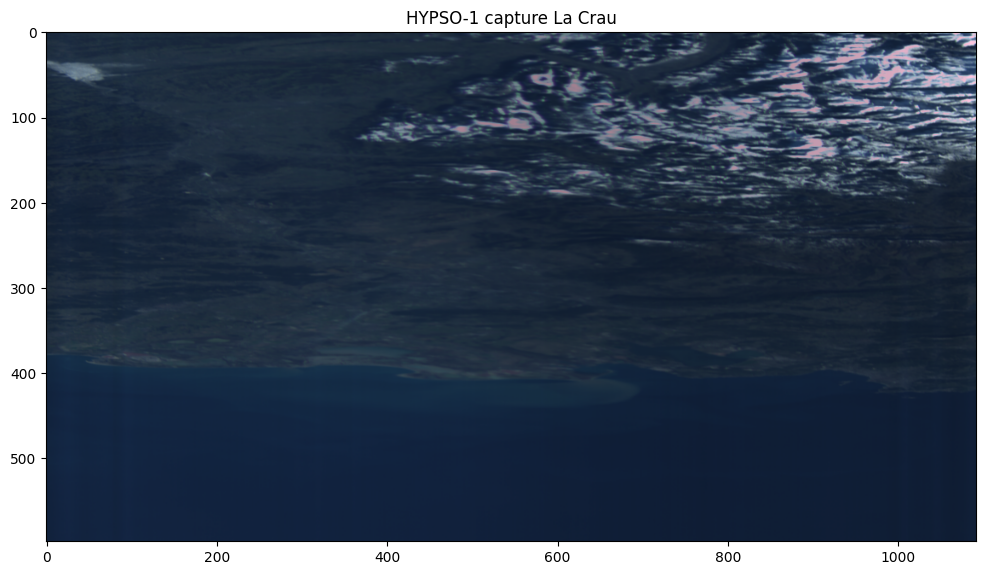

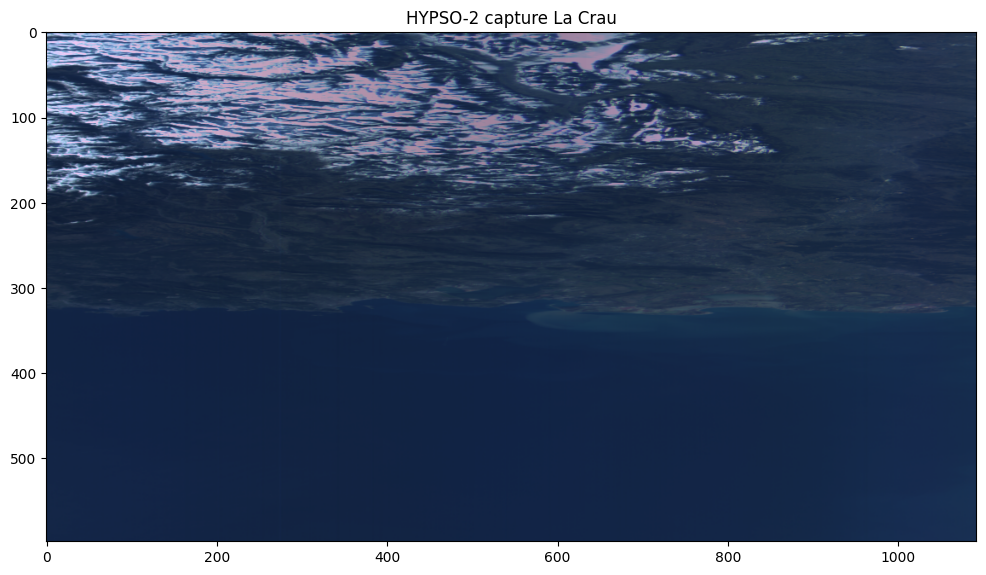

In [8]:

#R:630nm, G:550nm, B:480nm
# Red, Green, Blue, Alpha
red_wl = 630
green_wl = 550
blue_wl = 480

red_idx_h1 =   satobj_h1.get_closest_wavelength_index(red_wl)
green_idx_h1 = satobj_h1.get_closest_wavelength_index(green_wl)
blue_idx_h1 =  satobj_h1.get_closest_wavelength_index(blue_wl)

red_idx_h2 =   satobj_h2.get_closest_wavelength_index(red_wl)
green_idx_h2 = satobj_h2.get_closest_wavelength_index(green_wl)
blue_idx_h2 =  satobj_h2.get_closest_wavelength_index(blue_wl)


composite_h1 = (255*calibrated_cube_h1[:,:,[red_idx_h1, green_idx_h1, blue_idx_h1]]/calibrated_cube_h1[:,:,[red_idx_h1, green_idx_h1, blue_idx_h1]].max()).astype(int)
composite_h2 = (255*calibrated_cube_h2[:,:,[red_idx_h2, green_idx_h2, blue_idx_h2]]/calibrated_cube_h2[:,:,[red_idx_h2, green_idx_h2, blue_idx_h2]].max()).astype(int)
plt.figure(figsize=(12,12))
plt.title('HYPSO-1 capture La Crau')
plt.imshow(composite_h1)
# plt.axis('off')
plt.figure(figsize=(12,12))
plt.title('HYPSO-2 capture La Crau')
plt.imshow(composite_h2)
# plt.axis('off')

In [9]:
satobj_h2.generate_geometry()

[INFO] Running geometry computation...
ECI position samples: 30
Quaternion samples: 30
ADCS time range: 1735211100.000000 to 1735211970.000000
Frame time range: 1735211754.537797 to 1735211829.162797
3 sample(s) inside frame time range
Interpolating 598 frames
Spatial dimensions: 598 frames/lines, 1092 pixels/samples
Computing pixel latitude and longitude coordinates...
Interpolating pixel coordinate gaps...
Using geometry-computed latitude and longitude values
Computing local angles (sun and satellite azimuth and zenith angles)...
Image Center (lat,lon): (43.58527	004.45948)
Image Center elevation angle: 38.61780
Image Center off-nadir angle: 41.60153


In [10]:
satobj_h2.generate_toa_reflectance()

toa_rrs_cube_h2 = np.array(satobj_h2.get_toa_reflectance())

In [11]:
satobj_h1.generate_geometry()

[INFO] Running geometry computation...
ECI position samples: 430
Quaternion samples: 430
ADCS time range: 1735207980.000000 to 1735208940.000000
Frame time range: 1735208668.028188 to 1735208717.778188
199 sample(s) inside frame time range
Interpolating 598 frames
Spatial dimensions: 598 frames/lines, 1092 pixels/samples
Computing pixel latitude and longitude coordinates...
Interpolating pixel coordinate gaps...
Using geometry-computed latitude and longitude values
Computing local angles (sun and satellite azimuth and zenith angles)...
Image Center (lat,lon): (44.00719	004.61184)
Image Center elevation angle: 38.95816
Image Center off-nadir angle: 41.69267


In [12]:
satobj_h1.generate_toa_reflectance()

toa_rrs_cube_h1 = np.array(satobj_h1.get_toa_reflectance())

#### plot

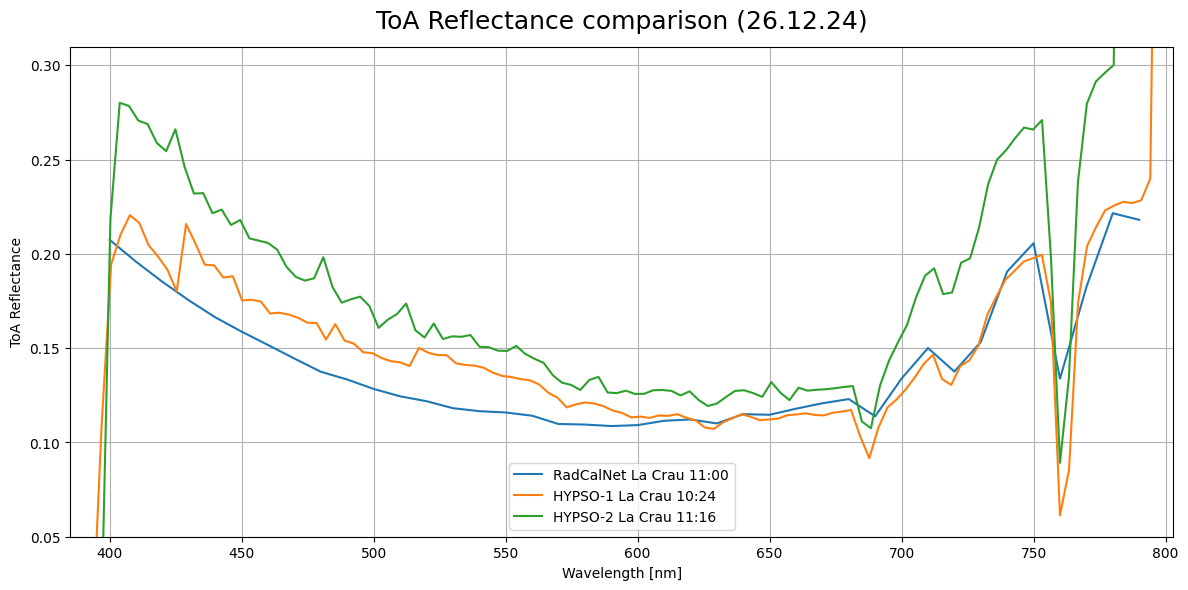

In [13]:
# pace_y, pace_x = 956, 513
x_gsp_h2, y_gsp_h2 = 305, 625
x_gsp_h1, y_gsp_h1 = 370, 470


x_min, x_max = 450,550
y_min, y_max = 700,800 

# manually found x and y limits for this particular case
x_limits = 385, 803
y_limits = 0.05, 0.31
# y_limits = 0.08, 0.3

region=1


plt.figure(figsize=(12,6))
plt.title('ToA Reflectance comparison (26.12.24)', fontsize=18, y=1.02)
plt.plot(ToA_reflectance[:40,0], ToA_reflectance[:40, 4])
plt.plot(satobj_h1.wavelengths[:]-1.4854441181661, toa_rrs_cube_h1[x_gsp_h1-region:x_gsp_h1+region, y_gsp_h1-region:y_gsp_h1+region, :].mean(axis=(0,1))) # wavelength mapping is not correct ...
plt.plot(satobj_h2.wavelengths[:]-4.1785207381841, toa_rrs_cube_h2[x_gsp_h2-region:x_gsp_h2+region, y_gsp_h2-region:y_gsp_h2+region, :].mean(axis=(0,1)))
plt.xlim(x_limits)
plt.ylim(y_limits)
plt.grid()
plt.xlabel('Wavelength [nm]')
plt.ylabel('ToA Reflectance')
plt.legend(['RadCalNet La Crau 11:00', 'HYPSO-1 La Crau 10:24', 'HYPSO-2 La Crau 11:16', 'PACE OCI l1b V3 La Crau 11:59'])

plt.tight_layout()

In [ ]:
np.savez('h1_lacrau_spectrum.npz', toa_rrs_cube_h1[x_gsp_h1-region:x_gsp_h1+region, y_gsp_h1-region:y_gsp_h1+region, :].mean(axis=(0,1)))
np.savez('h2_lacrau_spectrum.npz', toa_rrs_cube_h2[x_gsp_h2-region:x_gsp_h2+region, y_gsp_h2-region:y_gsp_h2+region, :].mean(axis=(0,1)))
np.savez('radcalnet_lacrau_spectrum.npz', ToA_reflectance[:40, 4])

np.savez('h1_lacrau_wavelengths.npz', satobj_h1.wavelengths[:]-1.4854441181661)
np.savez('h2_lacrau_wavelengths.npz', satobj_h2.wavelengths[:]-4.1785207381841)
np.savez('radcalnet_lacrau_wavelengths.npz', ToA_reflectance[:40,0])

: 